# Skip-gram Manual (Jaringan Saraf Tiruan) + Klasifikasi Naive Bayes

Notebook ini membangun **Skip-gram dari nol** (tanpa `gensim`), lengkap dengan:

1. **Preprocessing** teks berita (cleaning + tokenisasi)
2. **Pembuatan pasangan (target, context)** dari window Skip-gram
3. **One-hot encoding** untuk tiap pasangan -> `X[i]` = one-hot kata target, `Y[i]` = one-hot kata context
4. **Arsitektur jaringan saraf tiruan manual**:
   - Matrix bobot **input -> hidden** `W1` berukuran **(vocab_size x 3)** -> hidden layer 3 neuron (dimensi embedding)
   - Matrix bobot **hidden -> output** `W2` berukuran **(3 x vocab_size)** -> output = probabilitas tiap kata di vocabulary (softmax)
   - Forward pass, cross-entropy loss, backpropagation manual (tanpa autograd), update bobot dengan gradient descent
5. **Ekstraksi word embedding** dari `W1` hasil training
6. **Klasifikasi Naive Bayes**: representasi dokumen = rata-rata vektor kata (embedding) penyusunnya, lalu diklasifikasikan dengan `GaussianNB` ke label berita (mis. sport vs finance)

> Catatan: karena tidak ada file dataset yang diunggah, kode ini memakai struktur data yang sama dengan notebook sebelumnya (`../data/dataset_berita_200.xlsx`, kolom `id`, `isi_berita`, dan `label`). Sesuaikan nama kolom/path bila berbeda di dataset Anda.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load Data & Preprocessing

In [2]:
df = pd.read_excel("../data/dataset_berita_200.xlsx")

# Jika dataset punya kolom kategori, dipakai langsung.
# Jika belum ada, isi manual seperti contoh di bawah (silakan sesuaikan).
if "label" not in df.columns:
    df["label"] = "tidak_diketahui"

print(df[["id", "label"]].head())
print("Jumlah dokumen:", len(df))
print("Distribusi kategori:")
print(df["label"].value_counts())

   id  label
0   1  sport
1   2  sport
2   3  sport
3   4  sport
4   5  sport
Jumlah dokumen: 200
Distribusi kategori:
label
sport      100
finance    100
Name: count, dtype: int64


In [3]:
def bersihkan_ringan(teks):
    teks = str(teks).lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks

def tokenisasi(teks):
    return bersihkan_ringan(teks).split()

# Tokenisasi seluruh dokumen (dipakai untuk training skip-gram DAN untuk fitur klasifikasi)
df["tokens"] = df["isi_berita"].apply(tokenisasi)
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

print(df[["id", "label", "tokens"]].head())

   id  label                                             tokens
0   1  sport  [chef, de, mission, cdm, indonesia, todotua, p...
1   2  sport  [banjir, besar, melanda, nagoya, jepang, menje...
2   3  sport  [ketua, umum, komite, olimpiade, indonesia, ko...
3   4  sport  [persaingan, titel, juara, dunia, semakin, ket...
4   5  sport  [sektor, ganda, campuran, kembali, mengalami, ...


## 2. Vocabulary & One-Hot Encoding

In [4]:
semua_kalimat_token = df["tokens"].tolist()

vocab = sorted(set(kata for kalimat in semua_kalimat_token for kata in kalimat))
vocab_size = len(vocab)

word2idx = {kata: i for i, kata in enumerate(vocab)}
idx2word = {i: kata for kata, i in word2idx.items()}

print(f"Ukuran vocabulary: {vocab_size} kata")

def one_hot(idx, size=vocab_size):
    """Membuat vektor one-hot berdimensi `size` dengan 1 di posisi idx."""
    vek = np.zeros(size)
    vek[idx] = 1.0
    return vek

Ukuran vocabulary: 7439 kata


## 3. Pasangan (Target, Context) -> X (target) & Y (context)

Untuk tiap kata `target` dalam kalimat, kata-kata di sekitarnya dalam `window` dijadikan `context`.
Setiap pasangan diubah menjadi vektor one-hot: `X[i]` = one-hot target, `Y[i]` = one-hot context.

In [5]:
def buat_pasangan_skipgram(tokens, window=2):
    pasangan = []
    for i, target in enumerate(tokens):
        mulai = max(0, i - window)
        akhir = min(len(tokens), i + window + 1)
        for j in range(mulai, akhir):
            if j != i:
                pasangan.append((target, tokens[j]))
    return pasangan

WINDOW = 2
pasangan_kata = []
for tokens in semua_kalimat_token:
    pasangan_kata += buat_pasangan_skipgram(tokens, window=WINDOW)

print(f"Total pasangan (target, context): {len(pasangan_kata)}")
print("Contoh 5 pasangan pertama:", pasangan_kata[:5])

Total pasangan (target, context): 260500
Contoh 5 pasangan pertama: [('chef', 'de'), ('chef', 'mission'), ('de', 'chef'), ('de', 'mission'), ('de', 'cdm')]


In [ ]:
# Ubah setiap pasangan (target, context) kata menjadi indeks
pasangan_idx = [(word2idx[t], word2idx[c]) for t, c in pasangan_kata]

X_idx_semua = np.array([t_idx for t_idx, _ in pasangan_idx])  # indeks target, (N,)
Y_idx_semua = np.array([c_idx for _, c_idx in pasangan_idx])  # indeks context, (N,)

print("Jumlah pasangan:", X_idx_semua.shape[0])

# Demonstrasi bentuk one-hot X[i] (target) dan Y[i] (context) untuk beberapa pasangan pertama.
# CATATAN: one-hot untuk SELURUH pasangan sengaja TIDAK dibuat (X = matrix (260500 x 7439) ~15 GB)
# karena akan sangat boros memori dan tidak dipakai langsung saat training (lihat Bagian 4 & 5,
# training memakai indeks kata agar hemat memori).
N_DEMO = 5
X_demo = np.array([one_hot(t_idx) for t_idx in X_idx_semua[:N_DEMO]])
Y_demo = np.array([one_hot(c_idx) for c_idx in Y_idx_semua[:N_DEMO]])

print("\nContoh bentuk one-hot (5 pasangan pertama):")
print("X_demo shape:", X_demo.shape, "| Y_demo shape:", Y_demo.shape)
print("X_demo[0] (target one-hot):", X_demo[0])
print("Y_demo[0] (context one-hot):", Y_demo[0])

## 4. Arsitektur Jaringan Saraf Tiruan Skip-gram (Manual)

```
Input (one-hot, vocab_size)
        |  W1  (vocab_size x 3)   <- matrix bobot input->hidden
        v
Hidden (3 neuron / dimensi embedding)
        |  W2  (3 x vocab_size)   <- matrix bobot hidden->output
        v
Output (vocab_size, softmax)      <- probabilitas tiap kata jadi context
```

- `h = x . W1` (karena `x` one-hot, ini setara mengambil satu baris `W1`)
- `u = h . W2`
- `y_pred = softmax(u)`
- Loss: cross-entropy antara `y_pred` dan `y_true` (one-hot context)
- Backpropagation manual untuk update `W1` dan `W2`

In [35]:
import numpy as np
from scipy.sparse import csr_matrix

HIDDEN_DIM = 3

def softmax(u):
    u_stabil = u - np.max(u, axis=-1, keepdims=True)
    exp_u = np.exp(u_stabil)
    return exp_u / np.sum(exp_u, axis=-1, keepdims=True)


def to_onehot_sparse(idx_array, vocab_size):
    """One-hot encoding dalam bentuk sparse matrix."""
    N = idx_array.shape[0]
    data = np.ones(N, dtype=np.float32)
    rows = np.arange(N)
    cols = idx_array

    return csr_matrix(
        (data, (rows, cols)),
        shape=(N, vocab_size)
    )


class SkipGramManual:

    def __init__(
        self,
        vocab_size,
        hidden_dim,
        epochs=50,
        lr=1.0,
        batch_size=256
    ):
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

        # Konfigurasi training disimpan di dalam model
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size

        # Bobot Skip-Gram
        self.W1 = np.random.uniform(
            -0.5, 0.5,
            (vocab_size, hidden_dim)
        )

        self.W2 = np.random.uniform(
            -0.5, 0.5,
            (hidden_dim, vocab_size)
        )

    def forward(self, x_onehot):

        h = x_onehot @ self.W1
        u = h @ self.W2
        y_pred = softmax(u)

        return h, u, y_pred

    def backward(
        self,
        x_onehot,
        h,
        y_pred,
        y_onehot
    ):

        N = x_onehot.shape[0]

        e = y_pred - y_onehot
        e = np.asarray(e)

        dW2 = h.T @ e / N

        dh = e @ self.W2.T

        dW1 = (x_onehot.T @ dh) / N
        dW1 = np.asarray(dW1)

        self.W1 -= self.lr * dW1
        self.W2 -= self.lr * dW2

    def loss(self, y_pred, y_onehot):

        eps = 1e-9

        y_dense = (
            np.asarray(y_onehot.todense())
            if hasattr(y_onehot, "todense")
            else y_onehot
        )

        return -np.mean(
            np.sum(
                y_dense * np.log(y_pred + eps),
                axis=1
            )
        )

    def train(self, X, Y, verbose_every=5):

        history = []

        N = X.shape[0]

        for epoch in range(1, self.epochs + 1):

            idx = np.random.permutation(N)

            X_shuf = X[idx]
            Y_shuf = Y[idx]

            total_loss = 0.0
            n_batches = 0

            for start in range(
                0,
                N,
                self.batch_size
            ):

                xb_idx = X_shuf[
                    start:start + self.batch_size
                ]

                yb_idx = Y_shuf[
                    start:start + self.batch_size
                ]

                xb = to_onehot_sparse(
                    xb_idx,
                    self.vocab_size
                )

                yb = to_onehot_sparse(
                    yb_idx,
                    self.vocab_size
                )

                h, u, y_pred = self.forward(xb)

                total_loss += self.loss(
                    y_pred,
                    yb
                )

                n_batches += 1

                self.backward(
                    xb,
                    h,
                    y_pred,
                    yb
                )

            avg_loss = total_loss / n_batches

            history.append(avg_loss)

            if (
                epoch % verbose_every == 0
                or epoch == 1
            ):
                print(
                    f"Epoch {epoch:4d} | "
                    f"loss: {avg_loss:.4f}"
                )

        return history

In [36]:
WINDOW = 2

X_list, Y_list = [], []

for sent in tokenized_corpus:

    idxs = [
        word2idx[w]
        for w in sent
        if w in word2idx
    ]

    for i, center in enumerate(idxs):

        start = max(0, i - WINDOW)
        end = min(
            len(idxs),
            i + WINDOW + 1
        )

        for j in range(start, end):

            if j != i:

                X_list.append(center)
                Y_list.append(idxs[j])


X_idx = np.array(
    X_list,
    dtype=np.int32
)

Y_idx = np.array(
    Y_list,
    dtype=np.int32
)

print("Jumlah pasangan:", X_idx.shape[0])

Jumlah pasangan: 260500


In [ ]:
model_sg = SkipGramManual(
    vocab_size=vocab_size,
    hidden_dim=HIDDEN_DIM,
    epochs=100,   # dinaikkan dari 20 -> 100 supaya loss lebih konvergen
    lr=1.0,
    batch_size=256
)
history = model_sg.train(
    X_idx,
    Y_idx,
    verbose_every=10
)

## 5. Ekstraksi Word Embedding

Setelah training, `W1` (bobot input->hidden) menjadi tabel **embedding** kata: setiap baris ke-`i` adalah vektor 3 dimensi untuk kata dengan indeks `i`.

In [23]:
embedding_matrix = model_sg.W1  # (vocab_size x HIDDEN_DIM)

kata_contoh = vocab[0]
print(f"Vektor kata '{kata_contoh}':", np.round(embedding_matrix[word2idx[kata_contoh]], 4))

def vektor_kata(kata):
    return embedding_matrix[word2idx[kata]] if kata in word2idx else np.zeros(HIDDEN_DIM)

Vektor kata 'a': [ 0.3877  0.298  -0.0608]


## 6. Klasifikasi Naive Bayes

Representasi tiap dokumen = **rata-rata vektor embedding** dari kata-kata penyusunnya (dari `W1` hasil training Skip-gram manual). Fitur ini lalu dipakai untuk melatih **Gaussian Naive Bayes** memprediksi `kategori` berita.

In [25]:
def simple_preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# bikin kolom tokens LANGSUNG di df, supaya urutan baris tetap sejajar dengan label
df["tokens"] = df["isi_berita"].astype(str).apply(simple_preprocess)

print(df[["isi_berita", "tokens", "label"]].head())
print("Jumlah baris df:", len(df))

                                          isi_berita  \
0  Chef de Mission (CdM) Indonesia Todotua Pasari...   
1  Banjir besar melanda Nagoya, Jepang, menjelang...   
2  Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...   
3  Persaingan titel juara dunia semakin ketat men...   
4  Sektor ganda campuran kembali mengalami peromb...   

                                              tokens  label  
0  [chef, de, mission, cdm, indonesia, todotua, p...  sport  
1  [banjir, besar, melanda, nagoya, jepang, menje...  sport  
2  [ketua, umum, komite, olimpiade, indonesia, ko...  sport  
3  [persaingan, titel, juara, dunia, semakin, ket...  sport  
4  [sektor, ganda, campuran, kembali, mengalami, ...  sport  
Jumlah baris df: 200


In [26]:
def dokumen_ke_vektor(tokens):
    vek_kata = [vektor_kata(k) for k in tokens if k in word2idx]
    if len(vek_kata) == 0:
        return np.zeros(HIDDEN_DIM)
    return np.mean(vek_kata, axis=0)

df["fitur_embedding"] = df["tokens"].apply(dokumen_ke_vektor)

X_klasifikasi = np.vstack(df["fitur_embedding"].values)
y_klasifikasi = df["label"].values   # <-- diganti dari "kategori" jadi "label"

print("Bentuk fitur klasifikasi:", X_klasifikasi.shape)
print("Label unik:", np.unique(y_klasifikasi))

Bentuk fitur klasifikasi: (200, 3)
Label unik: ['finance' 'sport']


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_klasifikasi, y_klasifikasi, test_size=0.2, random_state=42,
    stratify=y_klasifikasi if len(np.unique(y_klasifikasi)) > 1 else None
)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Akurasi: 0.625

              precision    recall  f1-score   support

     finance       0.73      0.40      0.52        20
       sport       0.59      0.85      0.69        20

    accuracy                           0.62        40
   macro avg       0.66      0.62      0.61        40
weighted avg       0.66      0.62      0.61        40



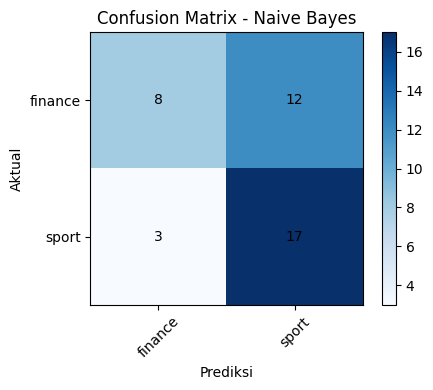

In [28]:
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.colorbar()
plt.xticks(range(len(nb_model.classes_)), nb_model.classes_, rotation=45)
plt.yticks(range(len(nb_model.classes_)), nb_model.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

## Ringkasan

- **Preprocessing**: cleaning ringan (lowercase, hapus tanda baca) + tokenisasi seluruh dokumen.
- **Pasangan Skip-gram**: dibentuk dari tiap kata target dan kata-kata di sekitarnya dalam `window`, lalu diubah menjadi vektor **one-hot** -> `X` (target) dan `Y` (context).
- **Jaringan saraf tiruan manual**: `W1` (vocab_size x 3) sebagai bobot input->hidden dan `W2` (3 x vocab_size) sebagai bobot hidden->output, dilatih dengan forward pass + softmax + cross-entropy loss + backpropagation manual (tanpa `gensim`/framework deep learning).
- **Word embedding**: diambil dari `W1` hasil training, tiap kata direpresentasikan sebagai vektor 3 dimensi.
- **Klasifikasi**: dokumen direpresentasikan sebagai rata-rata vektor kata penyusunnya, lalu diklasifikasikan ke kategori berita menggunakan **Gaussian Naive Bayes**, dievaluasi dengan akurasi, classification report, dan confusion matrix.